We want to solve $$ \dot Y_t^m = \mu(Y_t^m,t) + \varsigma(Y_t^m,t) \dot X_t^{m,-} + \sigma(Y_t^m,t) \dot W_t^m$$ where 
- $W$ is a $d$-dimensional Brownian motion, $X$ is 1-dimensional $H$-fBm, possibly correlated with $W$; $Y$ is $n$-dimensional
- The ${}^m$ denotes piecewise-linear approximations and the ${}^-$ means lagged w.r.t. $W$ by one interval
- $\mu$ and $\varsigma$ take values in $\mathbb R^n$, $\sigma$ takes values in $\mathbb R^{n \times d}$

We begin by focusing on the case of $H = 1/2$ and $\mathrm{d}[X,W^k]_t = \rho^k \mathrm{d}t$ for some $\rho^k \in [-1,1]$. The equation then becomes $$ \mathrm{d}Y_t = \Big( \mu(Y_t,t) + \frac{\rho^k}{2}[\sigma_k,\varsigma](Y_t,t) \Big)\mathrm{d}t + \varsigma(Y_t,t) \circ \mathrm{d}X_t^- + \sigma(Y_t,t) \circ \mathrm{d}W_t $$ where $[\sigma_k,\varsigma]$ denotes the Lie bracket $\mathrm{D}\varsigma \sigma_k - \mathrm{D}\sigma_k \varsigma$. Let's take $d = 3$ and $\rho^k = \delta^{1k}$.

In [2]:
# Imports
import jax
import jax.random as jr
import jax.numpy as jnp
import matplotlib.pyplot as plt
from diffrax import diffeqsolve, ControlTerm, Euler, MultiTerm, ODETerm, SaveAt, VirtualBrownianTree

In [84]:
# Global parameters, create brownian path(s)
t0, t1 = 0, 10
epsilon = 1e-3
times = jnp.arange(t0, t1, epsilon)
bm_control = VirtualBrownianTree(t0, t1, tol=epsilon, shape=(1,), key=jr.PRNGKey(0))

In [101]:
# Transform control (like brownian_motion) to array, so that it can be plotted
def control_to_array(grid, fun):
    return jax.vmap(lambda t: fun(t))(grid)
bm_array = control_to_array(times, bm_control.evaluate)
plt.plot(times,bm_array)
#plt.show()

In [105]:
# Create lagged control from a given control
def lagged_control(fun, lag):
    return lambda s,t: fun(jnp.maximum(0,t - lag)) - fun(jnp.maximum(0,s - lag))
lagged_bm_control = lagged_control(bm_control.evaluate, epsilon)

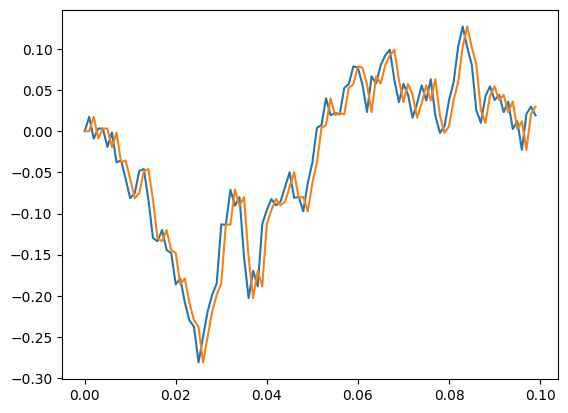

In [110]:
# Let's plot them side by side on a small interval
lagged_bm_array = control_to_array(times, lambda t: lagged_bm_control(0,t))
s0, s1 = 0, 100
plt.plot(times[s0:s1],bm_array[s0:s1])
plt.plot(times[s0:s1],lagged_bm_array[s0:s1])
plt.show()